# 01 — Bounding Box Annotation Demo

This notebook accompanies `01-data-labeling-and-annotation-aws-ground-truth.md`.

It demonstrates, fully offline with synthetic data:

1. Generating a synthetic "document" image with a couple of chart-like rectangular shapes using PIL.
2. Manually defining ground-truth bounding boxes for those shapes (exactly what a human annotator
   would produce in an AWS Ground Truth bounding-box labeling job).
3. Visualizing the boxes over the image with matplotlib.
4. Simulating **two different annotators** labeling the same objects with slightly different boxes,
   and computing their **inter-annotator agreement** using IOU — the same quality-control technique
   described in Chapter 01 for measuring labeling consistency across a collaborative Ground Truth
   workforce.

No AWS credentials, no internet access, and no GPU are required — everything runs on CPU with
`numpy`, `PIL`, and `matplotlib`.

## 1. Generate a synthetic "document" image

We build a simple raster image that mimics a slide/document page: a block of "body text" (thin gray
bars) at the top, and two chart-like shapes (a rectangle border, axis lines, and a few bars) placed
at fixed locations. Because we draw these ourselves, we already know the exact ground-truth bounding
box for each chart-like shape — this mirrors how, in AWS Ground Truth, a human annotator would draw
these same boxes by hand while looking at the image.

In [1]:
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

IMG_W, IMG_H = 640, 480


def make_synthetic_document(width=IMG_W, height=IMG_H):
    """A blank 'page' with a few lines of simulated body text at the top."""
    img = Image.new("RGB", (width, height), color=(250, 250, 248))
    draw = ImageDraw.Draw(img)
    for y in range(20, 90, 14):
        draw.rectangle([30, y, int(rng.integers(300, 560)), y + 8], fill=(200, 200, 205))
    return img, draw


def draw_chart_like_shape(draw, box, seed):
    """Draws a simple bar-chart-like shape (border, axes, bars) inside `box`."""
    x1, y1, x2, y2 = box
    r = np.random.default_rng(seed)
    draw.rectangle(box, outline=(30, 30, 30), width=2)
    draw.line([x1 + 10, y2 - 10, x1 + 10, y1 + 10], fill=(30, 30, 30), width=2)  # y-axis
    draw.line([x1 + 10, y2 - 10, x2 - 10, y2 - 10], fill=(30, 30, 30), width=2)  # x-axis
    n_bars = 5
    bar_w = (x2 - x1 - 30) / n_bars
    for i in range(n_bars):
        bar_h = int(r.integers(20, y2 - y1 - 40))
        bx1 = x1 + 15 + i * bar_w
        bx2 = bx1 + bar_w * 0.6
        by2 = y2 - 12
        by1 = by2 - bar_h
        draw.rectangle([bx1, by1, bx2, by2], fill=(90, 130, 200))


img, draw = make_synthetic_document()

# Ground-truth bounding boxes, in (x_min, y_min, x_max, y_max) pixel format --
# this is the "corner format" convention described in Chapter 01. A real
# Ground Truth job would have a human draw these; here we define them
# directly since we're also the ones generating the synthetic shapes.
ground_truth_boxes = [
    (60, 120, 300, 320),
    (350, 150, 600, 300),
]

for i, box in enumerate(ground_truth_boxes):
    draw_chart_like_shape(draw, box, seed=100 + i)

print("Generated image size:", img.size)
print("Ground truth boxes (x_min, y_min, x_max, y_max):")
for i, b in enumerate(ground_truth_boxes):
    print(f"  chart {i}: {b}")

Generated image size: (640, 480)
Ground truth boxes (x_min, y_min, x_max, y_max):
  chart 0: (60, 120, 300, 320)
  chart 1: (350, 150, 600, 300)


## 2. Visualize the ground-truth boxes

This is the annotator's-eye view: the synthetic document with the two chart regions outlined in
green, exactly as they'd appear overlaid on an image inside the AWS Ground Truth bounding-box
labeling UI.

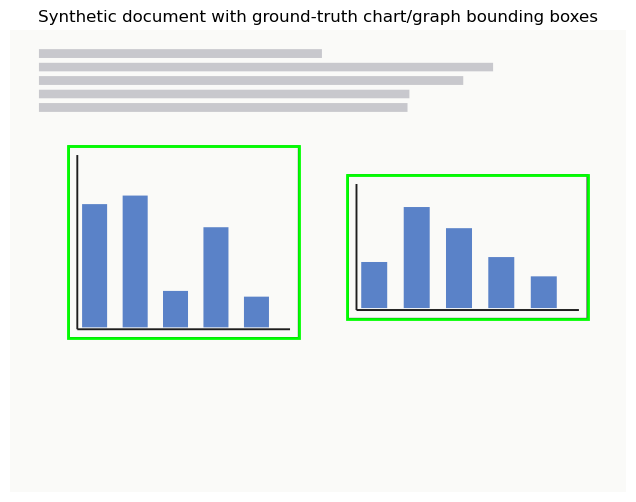

In [2]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(img)
for (x1, y1, x2, y2) in ground_truth_boxes:
    ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                fill=False, edgecolor="lime", linewidth=2))
ax.set_title("Synthetic document with ground-truth chart/graph bounding boxes")
ax.axis("off")
plt.show()

## 3. Simulate two annotators labeling the same objects

In a real "collaborative labeling" job (Chapter 01), more than one person may annotate the same or
overlapping images, and no two humans draw pixel-identical boxes. We simulate that here by taking
the true ground-truth boxes and applying small random pixel offsets to each corner — independently
for "Annotator A" and "Annotator B" — representing the natural, small disagreements real labelers
produce even when they're both trying to box the same object correctly.

In [3]:
def jitter_box(box, rng, max_jitter=12):
    """Randomly perturbs each corner of a box by up to +/- max_jitter pixels,
    simulating natural disagreement between two human annotators."""
    x1, y1, x2, y2 = box
    dx1, dy1, dx2, dy2 = rng.integers(-max_jitter, max_jitter, size=4)
    return (x1 + dx1, y1 + dy1, x2 + dx2, y2 + dy2)


rng_a = np.random.default_rng(7)
rng_b = np.random.default_rng(13)

annotator_a_boxes = [jitter_box(b, rng_a) for b in ground_truth_boxes]
annotator_b_boxes = [jitter_box(b, rng_b) for b in ground_truth_boxes]

print("Annotator A boxes:", annotator_a_boxes)
print("Annotator B boxes:", annotator_b_boxes)

Annotator A boxes: [(70, 123, 304, 329), (351, 156, 608, 293)]
Annotator B boxes: [(69, 128, 307, 328), (339, 157, 610, 294)]


## 4. Compute inter-annotator agreement with IOU

Just like the model-evaluation IOU used in Chapter 03, we can use IOU to measure how much two
*annotators'* boxes for the same object agree with each other. A low average IOU across a sample of
double-annotated images is the practical signal Chapter 01 describes for "the labeling instructions
are ambiguous" or "this class definition needs clarification" — it's the same overlap math, just
applied to quality control instead of model evaluation.

In [4]:
def iou(box_a, box_b):
    """Intersection over Union between two (x_min, y_min, x_max, y_max) boxes."""
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b

    inter_x1, inter_y1 = max(xa1, xb1), max(ya1, yb1)
    inter_x2, inter_y2 = min(xa2, xb2), min(ya2, yb2)
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)

    area_a = (xa2 - xa1) * (ya2 - ya1)
    area_b = (xb2 - xb1) * (yb2 - yb1)
    union_area = area_a + area_b - inter_area

    return inter_area / union_area if union_area > 0 else 0.0


agreements = [iou(a, b) for a, b in zip(annotator_a_boxes, annotator_b_boxes)]
for idx, agr in enumerate(agreements):
    print(f"Object {idx}: Annotator A vs Annotator B IOU = {agr:.3f}")

print(f"\nMean inter-annotator agreement (IOU): {np.mean(agreements):.3f}")

Object 0: Annotator A vs Annotator B IOU = 0.955
Object 1: Annotator A vs Annotator B IOU = 0.935

Mean inter-annotator agreement (IOU): 0.945


## 5. Visualize both annotators' boxes side by side

Green = Annotator A, orange = Annotator B, dashed white = the true ground truth. This is the kind of
overlay a labeling-quality reviewer would look at when deciding whether two annotators' work is
consistent enough to accept, or whether it needs adjudication (Chapter 01).

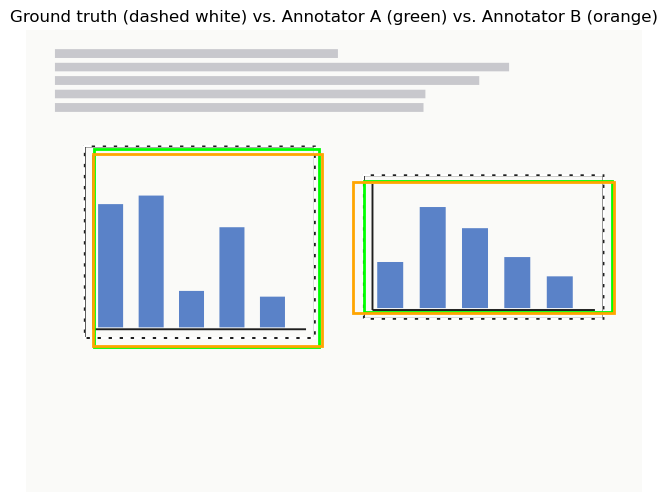

Takeaway: a mean IOU around 0.9+ between annotators, like we see here, is a strong signal
of consistent labeling instructions -- the kind of agreement a Ground Truth quality review
would be happy to accept without adjudication. A much lower mean IOU would be a signal to
revisit the labeling instructions or flag the objects for senior review, per Chapter 01.


In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(img)
for (x1, y1, x2, y2) in ground_truth_boxes:
    ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                fill=False, edgecolor="white", linewidth=1.5, linestyle="--"))
for (x1, y1, x2, y2) in annotator_a_boxes:
    ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                fill=False, edgecolor="lime", linewidth=2))
for (x1, y1, x2, y2) in annotator_b_boxes:
    ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                fill=False, edgecolor="orange", linewidth=2))

ax.set_title("Ground truth (dashed white) vs. Annotator A (green) vs. Annotator B (orange)")
ax.axis("off")
plt.show()

print("Takeaway: a mean IOU around 0.9+ between annotators, like we see here, is a strong signal")
print("of consistent labeling instructions -- the kind of agreement a Ground Truth quality review")
print("would be happy to accept without adjudication. A much lower mean IOU would be a signal to")
print("revisit the labeling instructions or flag the objects for senior review, per Chapter 01.")